In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [19]:
# Load the dataset (update filename if needed)
df = pd.read_excel(r'C:/Users/emangwapo/Downloads/Asteroid Data Clean.xlsx')

In [20]:
# Display first few rows
df.head()

,id,response_id,asteroid_id,name,nasa_jpl_url,absolute_magnitude,is_potentially_hazardous,diameter_min_m,diameter_max_m,close_approach_date,miss_distance_km,relative_velocity_kps
0,1,1,3724393,(2015 OD22),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,21.21,f,152.249185,340.439527,2024-01-01,6.541738e+07,25.393165
1,2,1,3797695,(2018 BA),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,25.00,f,26.580000,59.434687,2024-01-01,5.925668e+07,16.705187
2,3,1,3986699,(2020 BC),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,26.20,f,15.295194,34.201092,2024-01-01,2.507066e+07,8.314177
3,4,1,54200446,(2021 SG2),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,25.54,f,20.727884,46.348958,2024-01-01,7.179448e+07,19.260123
4,5,1,54235663,(2022 AO2),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,24.19,f,38.597127,86.305799,2024-01-01,5.504957e+07,19.513593


In [22]:
# -----------------------------
# Summary Statistics
# -----------------------------
df.describe(include='all')

,id,response_id,asteroid_id,name,nasa_jpl_url,absolute_magnitude,is_potentially_hazardous,diameter_min_m,diameter_max_m,close_approach_date,miss_distance_km,relative_velocity_kps
count,1091.000000,1091.000000,1.091000e+03,1091,1091,1091.000000,1091,1091.000000,1091.000000,1091,1.091000e+03,1091.000000
unique,NaN,NaN,NaN,1091,1091,NaN,2,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,(2015 OD22),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,NaN,f,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1,1,NaN,1028,NaN,NaN,NaN,NaN,NaN
mean,546.000000,30.790101,3.603810e+07,NaN,NaN,24.336040,NaN,82.812565,185.174526,2024-01-30 18:57:44.711273984,3.174171e+07,12.928306
min,1.000000,1.000000,2.001685e+06,NaN,NaN,14.280000,NaN,0.913177,2.041926,2024-01-01 00:00:00,1.058801e+05,0.393950
25%,273.500000,16.000000,3.778763e+06,NaN,NaN,22.355000,NaN,14.947032,33.422581,2024-01-16 00:00:00,1.026646e+07,7.704893
50%,546.000000,31.000000,5.430805e+07,NaN,NaN,24.670000,NaN,30.942470,69.189466,2024-01-31 00:00:00,2.856450e+07,11.748495
75%,818.500000,45.000000,5.442315e+07,NaN,NaN,26.250000,NaN,89.857872,200.928309,2024-02-14 00:00:00,5.336082e+07,17.098472
max,1091.000000,60.000000,5.454254e+07,NaN,NaN,32.320000,NaN,3703.010782,8280.183830,2024-02-29 00:00:00,7.468203e+07,44.866916


In [25]:
# -----------------------------
# Missing Value Analysis
# -----------------------------
df.isna().sum()

id                          0
response_id                 0
asteroid_id                 0
name                        0
nasa_jpl_url                0
absolute_magnitude          0
is_potentially_hazardous    0
diameter_min_m              0
diameter_max_m              0
close_approach_date         0
miss_distance_km            0
relative_velocity_kps       0
dtype: int64

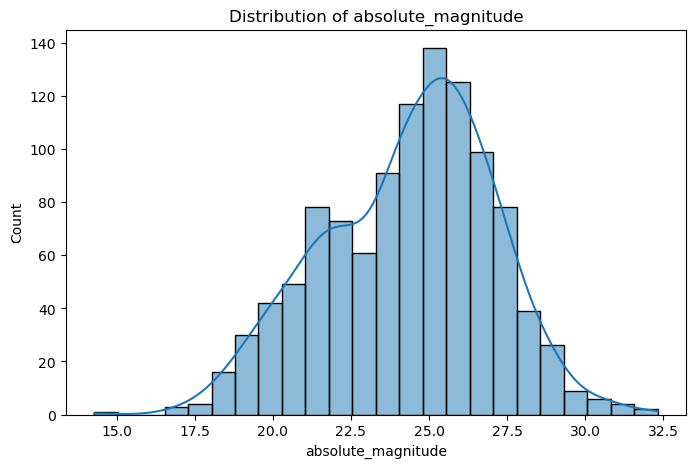

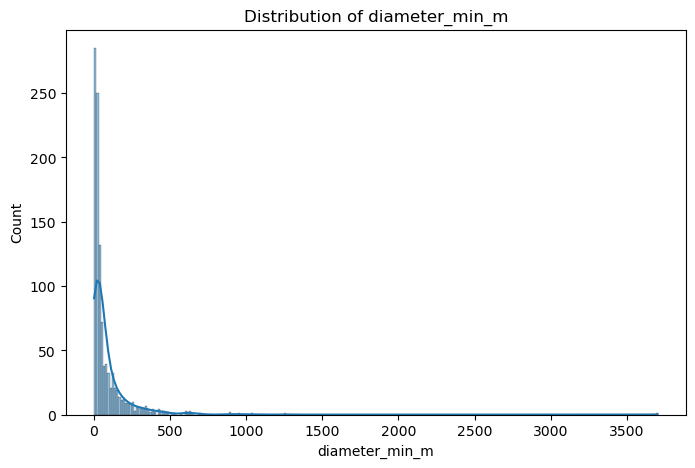

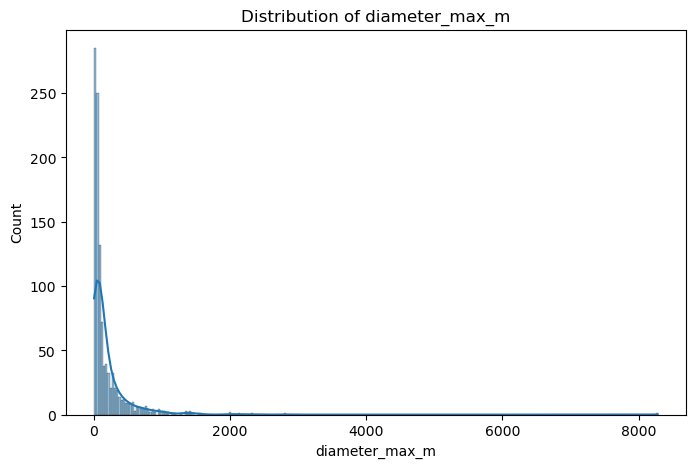

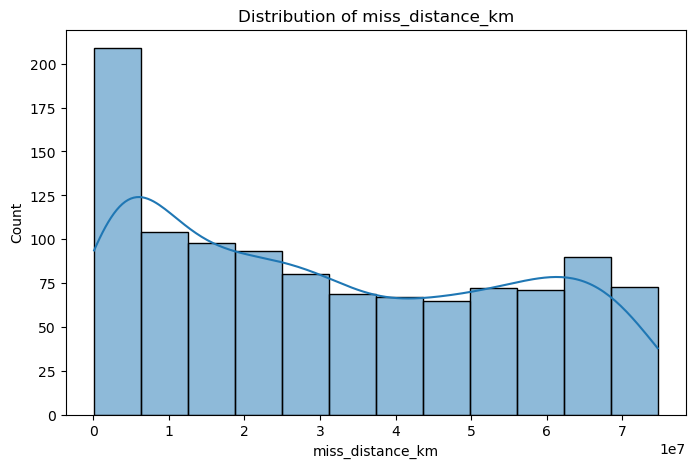

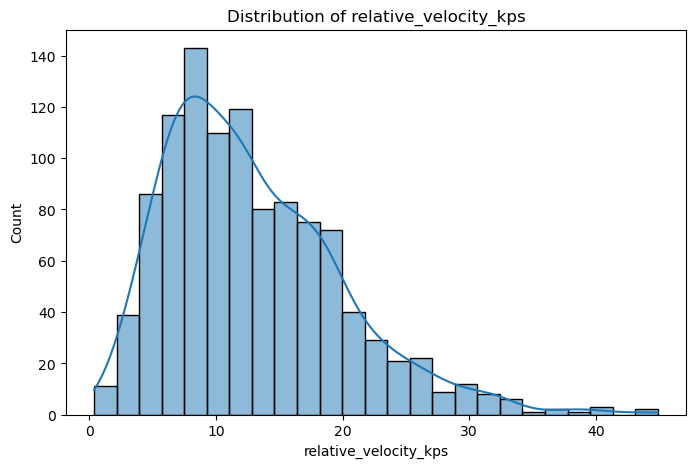

In [37]:
# -----------------------------
# Distribution Plots
# -----------------------------
numeric_cols = [
    'absolute_magnitude',
    'diameter_min_m',
    'diameter_max_m',
    'miss_distance_km',
    'relative_velocity_kps'
]

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()

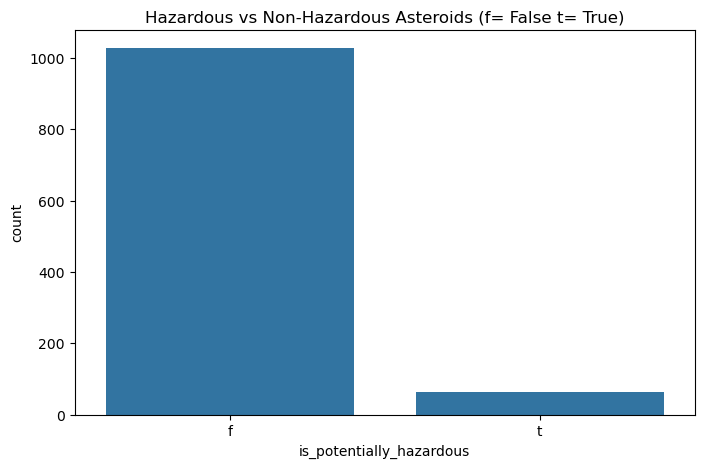

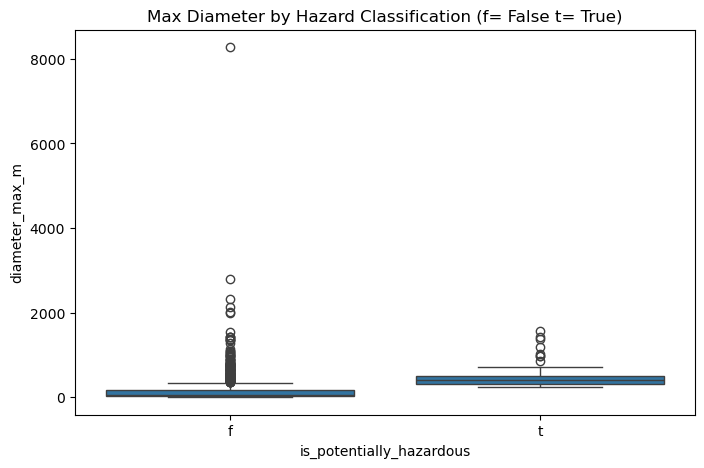

In [47]:
# -----------------------------
# Hazardous vs Non-Hazardous Comparison
# -----------------------------
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='is_potentially_hazardous')
plt.title("Hazardous vs Non-Hazardous Asteroids (f= False t= True)")
plt.show()

# Diameter comparison (use min diameter)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='is_potentially_hazardous', y='diameter_max_m')
plt.title("Max Diameter by Hazard Classification (f= False t= True)")
plt.show()

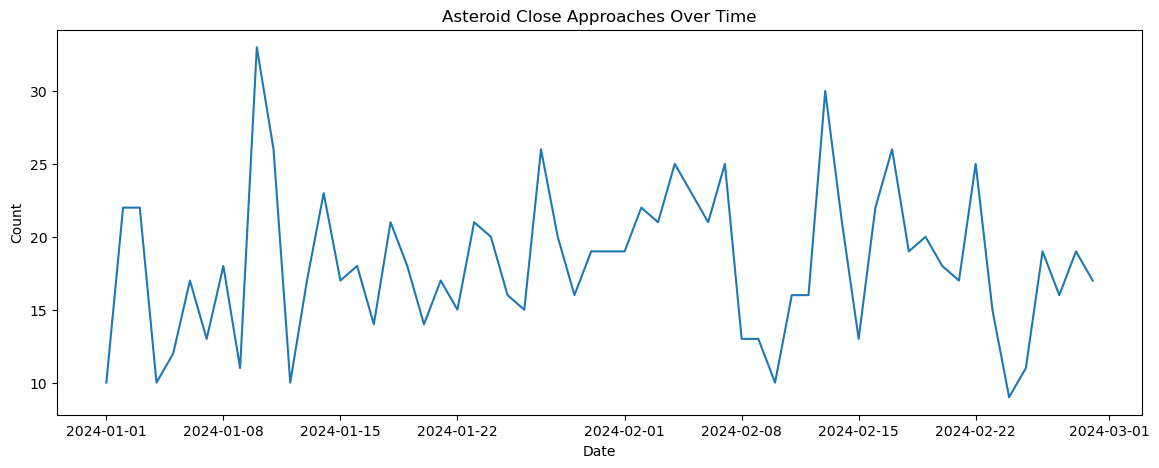

In [49]:
# -----------------------------
# Time-Series: Close Approach Dates
# -----------------------------
df['close_approach_date'] = pd.to_datetime(df['close_approach_date'], errors='coerce')

daily_counts = df.groupby('close_approach_date').size()

plt.figure(figsize=(14,5))
plt.plot(daily_counts.index, daily_counts.values)
plt.title("Asteroid Close Approaches Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()